# 新公开水质数据集：多分类训练、评估与预测

本笔记本使用 `new-water-data.csv` 的原始 `class` 标签完成独立的多分类实验。`sample_id` 仅用于追溯记录，不参与模型训练。所有输出保存在当前 `new-train` 文件夹。

In [1]:
# 1. 导入依赖与设置随机种子
from pathlib import Path
import random
import warnings

import joblib
import matplotlib.pyplot as plt
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, make_scorer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

# 显式注册 Windows 中文字体，防止 Matplotlib 回退为缺字形的默认字体。
font_path = Path('C:/Windows/Fonts/msyh.ttc')
if not font_path.exists():
    raise FileNotFoundError(f'未找到中文字体文件: {font_path}')
font_manager.fontManager.addfont(str(font_path))
chinese_font = font_manager.FontProperties(fname=str(font_path)).get_name()
sns.set_theme(style='whitegrid', font=chinese_font)
plt.rcParams['font.family'] = chinese_font
plt.rcParams['font.sans-serif'] = [chinese_font]
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'new-water-data.csv'
OUTPUT_DIR = BASE_DIR / '图片'
OUTPUT_DIR.mkdir(exist_ok=True)

print(f'中文绘图字体: {chinese_font}')
print(f'工作目录: {BASE_DIR}')
print(f'数据文件: {DATA_PATH.name}')

中文绘图字体: Microsoft YaHei
工作目录: C:\Users\slan\OneDrive - GN Store Nord\Desktop\personal\ML\new-train
数据文件: new-water-data.csv


In [2]:
# 2. 加载并检查水质数据集
df_raw = pd.read_csv(DATA_PATH)
print(f'数据形状: {df_raw.shape}')
display(df_raw.head())
print('\n字段类型:')
display(df_raw.dtypes.to_frame('数据类型'))
print('\n缺失值统计:')
display(df_raw.isna().sum().to_frame('缺失值数'))
print('\n类别分布:')
display(df_raw['class'].value_counts().rename_axis('class').reset_index(name='样本数'))

数据形状: (2153, 8)


,sample_id,ec_uScm,tds_mgL,turbidity_NTU,temp_C,pH,do_mgL,class
0,1507,19.14,6.07,130.13,21.86,9.35,11.69,Warning
1,1768,1831.09,1017.97,52.15,20.17,9.32,2.33,Warning
2,890,40.52,29.74,35.69,30.10,6.49,9.09,Caution
3,307,442.84,221.24,17.30,25.51,7.71,6.09,Normal
4,1774,1790.43,859.00,132.55,32.56,5.62,2.82,Warning



字段类型:


,数据类型
sample_id,int64
ec_uScm,float64
tds_mgL,float64
turbidity_NTU,float64
temp_C,float64
pH,float64
do_mgL,float64
class,object



缺失值统计:


,缺失值数
sample_id,0
ec_uScm,0
tds_mgL,0
turbidity_NTU,0
temp_C,0
pH,0
do_mgL,0
class,0



类别分布:


,class,样本数
0,Caution,670
1,Normal,638
2,Warning,478
3,Severe,367


In [3]:
# 3. 清洗数据与定义特征标签
feature_columns = ['ec_uScm', 'tds_mgL', 'turbidity_NTU', 'temp_C', 'pH', 'do_mgL']
target_column = 'class'
id_column = 'sample_id'

missing_columns = set(feature_columns + [target_column, id_column]) - set(df_raw.columns)
if missing_columns:
    raise ValueError(f'数据缺少必要字段: {sorted(missing_columns)}')

df_clean = df_raw.copy()
for column in feature_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
df_clean[target_column] = df_clean[target_column].astype('string').str.strip()

initial_rows = len(df_clean)
duplicate_rows = int(df_clean.duplicated().sum())
empty_labels = int((df_clean[target_column].isna() | df_clean[target_column].eq('')).sum())
df_clean = df_clean.drop_duplicates().dropna(subset=[target_column]).reset_index(drop=True)

summary_rows = [
    {'指标': '原始样本数', '数值': initial_rows},
    {'指标': '移除重复完整记录数', '数值': duplicate_rows},
    {'指标': '移除空标签记录数', '数值': empty_labels},
    {'指标': '清理后样本数', '数值': len(df_clean)},
]
for column in feature_columns:
    summary_rows.append({'指标': f'{column} 缺失值数', '数值': int(df_clean[column].isna().sum())})

cleaning_report = pd.DataFrame(summary_rows)
cleaning_report.to_csv(BASE_DIR / '数据清理报告.csv', index=False, encoding='utf-8-sig')
df_clean.to_csv(BASE_DIR / 'new-water-data-cleaned.csv', index=False, encoding='utf-8-sig')

display(cleaning_report)
print('说明：数值极端值被保留，因为其可能对应真实的严重水质状态；缺失值将在模型管道内按训练折中位数填补。')

X = df_clean[feature_columns].copy()
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_clean[target_column])
class_names = label_encoder.classes_.tolist()
print(f'类别映射: {dict(enumerate(class_names))}')

,指标,数值
0,原始样本数,2153
1,移除重复完整记录数,0
2,移除空标签记录数,0
3,清理后样本数,2153
4,ec_uScm 缺失值数,0
5,tds_mgL 缺失值数,0
6,turbidity_NTU 缺失值数,0
7,temp_C 缺失值数,0
8,pH 缺失值数,0
9,do_mgL 缺失值数,0


说明：数值极端值被保留，因为其可能对应真实的严重水质状态；缺失值将在模型管道内按训练折中位数填补。
类别映射: {0: 'Caution', 1: 'Normal', 2: 'Severe', 3: 'Warning'}


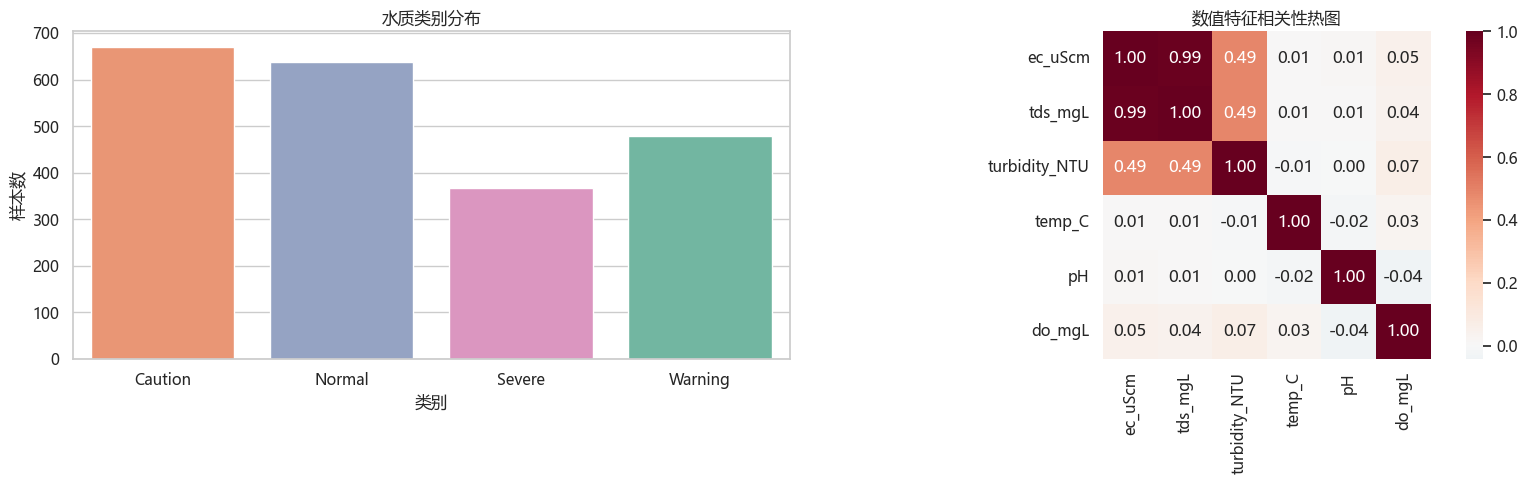

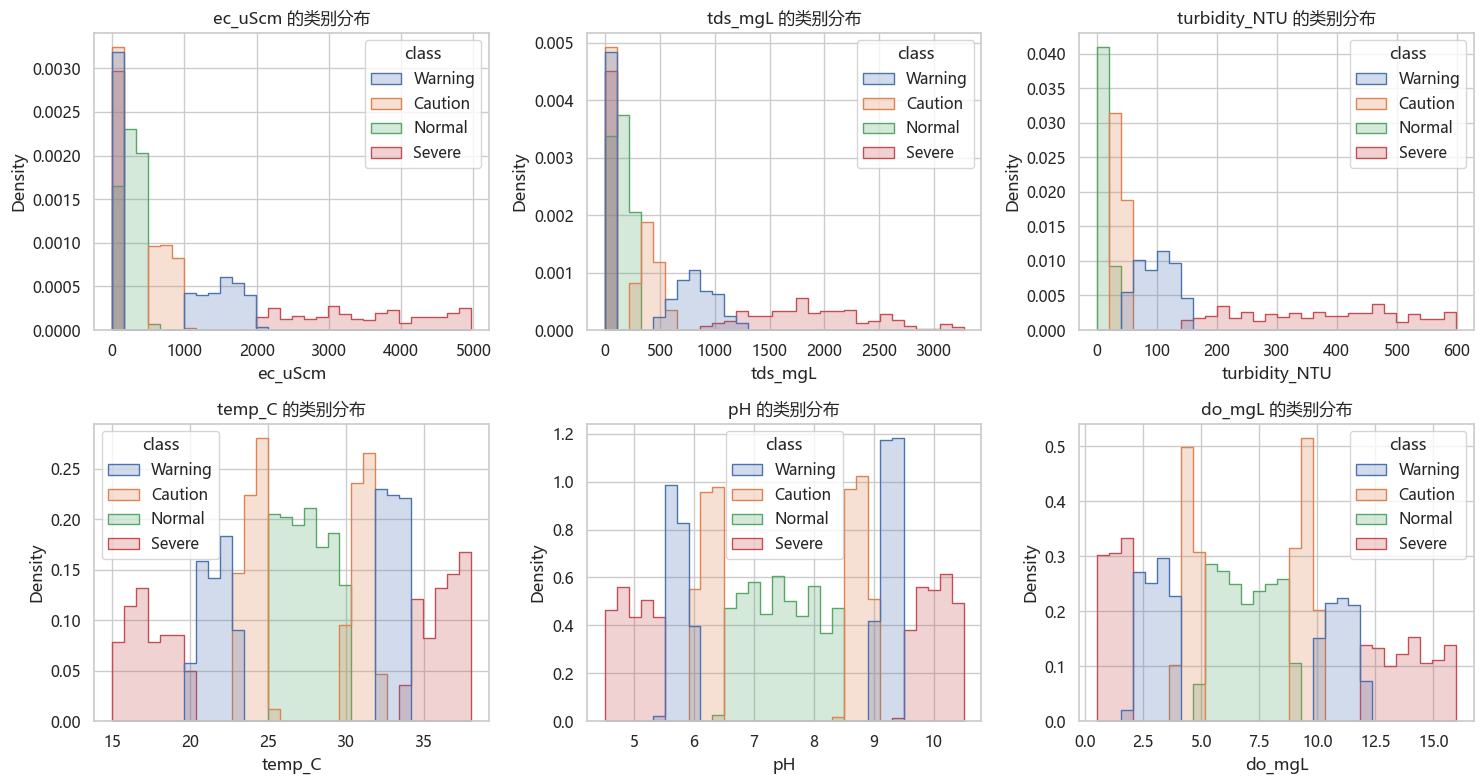

In [4]:
# 数据探索：类别、特征分布和相关性
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=df_clean, x=target_column, order=class_names, hue=target_column, legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('水质类别分布')
axes[0].set_xlabel('类别')
axes[0].set_ylabel('样本数')

correlation = df_clean[feature_columns].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, ax=axes[1])
axes[1].set_title('数值特征相关性热图')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '类别分布与特征相关性.png', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.ravel(), feature_columns):
    sns.histplot(data=df_clean, x=column, hue=target_column, bins=30, element='step', stat='density', common_norm=False, ax=axis)
    axis.set_title(f'{column} 的类别分布')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '特征分布.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# 4. 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y
)

train_distribution = pd.Series(y_train).map(dict(enumerate(class_names))).value_counts().reindex(class_names)
test_distribution = pd.Series(y_test).map(dict(enumerate(class_names))).value_counts().reindex(class_names)
display(pd.DataFrame({'训练集': train_distribution, '测试集': test_distribution}))
print(f'训练集大小: {X_train.shape}; 测试集大小: {X_test.shape}')

numeric_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
tree_preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'accuracy': 'accuracy',
    'f1_weighted': make_scorer(f1_score, average='weighted'),
    'f1_macro': make_scorer(f1_score, average='macro')
}

,训练集,测试集
Caution,402,268
Normal,382,256
Severe,220,147
Warning,287,191


训练集大小: (1291, 6); 测试集大小: (862, 6)


In [6]:
# 5. 构建预处理与七个分类模型管道
models = {
    'Gaussian Naive Bayes': Pipeline([('preprocess', numeric_preprocessor), ('model', GaussianNB())]),
    '逻辑回归': Pipeline([('preprocess', numeric_preprocessor), ('model', LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))]),
    'KNN': Pipeline([('preprocess', numeric_preprocessor), ('model', KNeighborsClassifier(n_neighbors=11, weights='distance'))]),
    'RBF-SVM': Pipeline([('preprocess', numeric_preprocessor), ('model', SVC(C=3, kernel='rbf', probability=True, random_state=RANDOM_STATE))]),
    '决策树': Pipeline([('preprocess', tree_preprocessor), ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))]),
    '随机森林': Pipeline([('preprocess', tree_preprocessor), ('model', RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight='balanced', n_jobs=1))]),
    'XGBoost': Pipeline([('preprocess', tree_preprocessor), ('model', XGBClassifier(objective='multi:softprob', num_class=len(class_names), n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=1))])
}
print('已建立模型：')
for name in models:
    print('-', name)

已建立模型：
- Gaussian Naive Bayes
- 逻辑回归
- KNN
- RBF-SVM
- 决策树
- 随机森林
- XGBoost


,模型,准确率均值,准确率标准差,加权F1均值,宏平均F1均值
0,随机森林,1.0000,0.0000,1.0000,1.0000
1,RBF-SVM,0.9992,0.0016,0.9992,0.9990
2,决策树,0.9992,0.0016,0.9992,0.9990
3,XGBoost,0.9961,0.0035,0.9961,0.9958
4,KNN,0.9853,0.0071,0.9851,0.9809
5,Gaussian Naive Bayes,0.9845,0.0074,0.9844,0.9827
6,逻辑回归,0.9125,0.0222,0.9119,0.9143


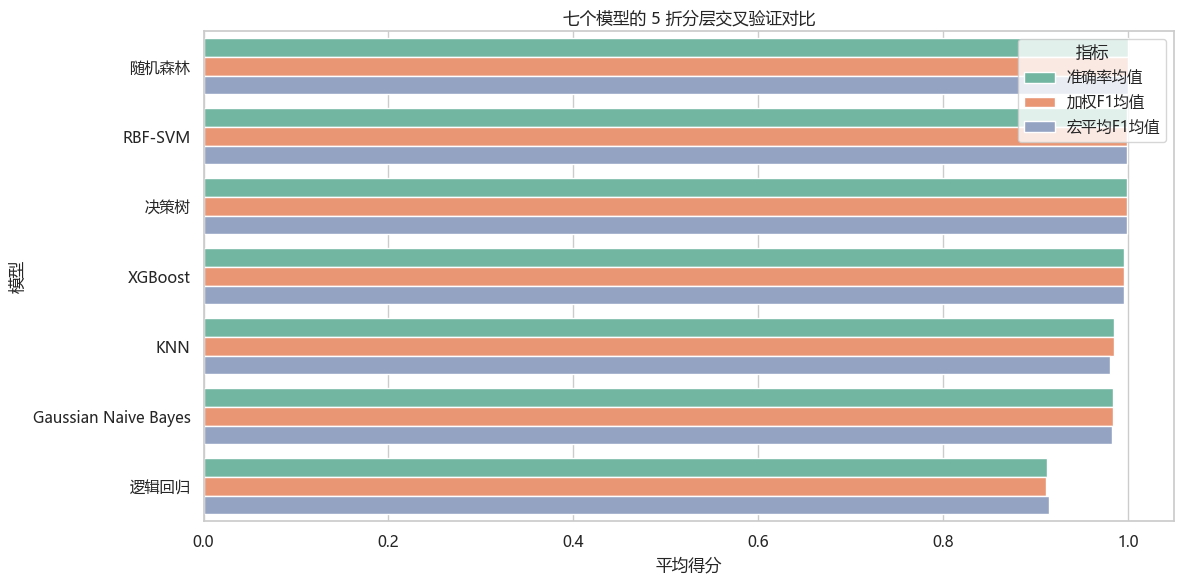

In [7]:
# 6. 七模型交叉验证对比（只在训练集上进行）
cv_rows = []
for model_name, estimator in models.items():
    scores = cross_validate(estimator, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        '模型': model_name,
        '准确率均值': scores['test_accuracy'].mean(),
        '准确率标准差': scores['test_accuracy'].std(),
        '加权F1均值': scores['test_f1_weighted'].mean(),
        '宏平均F1均值': scores['test_f1_macro'].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values('加权F1均值', ascending=False).reset_index(drop=True)
cv_results.to_csv(BASE_DIR / '模型交叉验证结果汇总表.csv', index=False, encoding='utf-8-sig')
display(cv_results.style.format({column: '{:.4f}' for column in cv_results.columns[1:]}))

plot_df = cv_results.melt(id_vars='模型', value_vars=['准确率均值', '加权F1均值', '宏平均F1均值'], var_name='指标', value_name='分数')
plt.figure(figsize=(12, 6))
sns.barplot(data=plot_df, x='分数', y='模型', hue='指标', palette='Set2')
plt.xlim(0, 1.05)
plt.title('七个模型的 5 折分层交叉验证对比')
plt.xlabel('平均得分')
plt.ylabel('模型')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '七模型交叉验证对比.png', dpi=300, bbox_inches='tight')
plt.show()

基线随机森林测试集准确率: 1.0000
基线随机森林测试集加权 F1: 1.0000
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       268
      Normal       1.00      1.00      1.00       256
      Severe       1.00      1.00      1.00       147
     Warning       1.00      1.00      1.00       191

    accuracy                           1.00       862
   macro avg       1.00      1.00      1.00       862
weighted avg       1.00      1.00      1.00       862



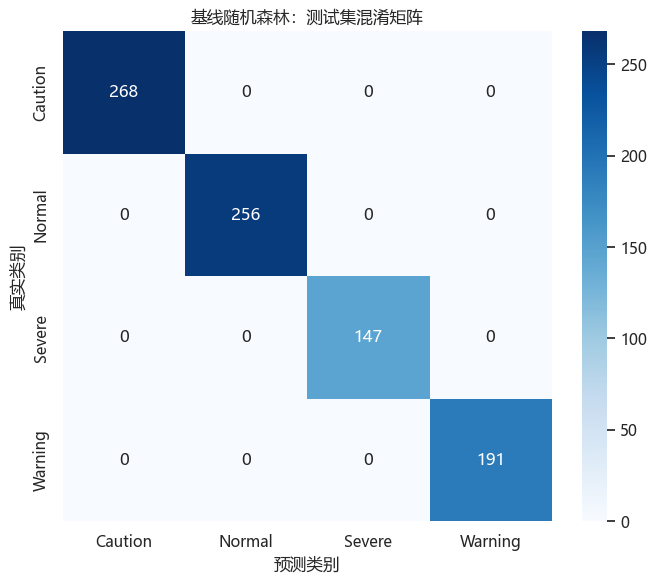

In [8]:
# 7. 基线随机森林训练、预测与混淆矩阵
baseline_rf = models['随机森林']
baseline_rf.fit(X_train, y_train)
y_pred_baseline = baseline_rf.predict(X_test)
y_prob_baseline = baseline_rf.predict_proba(X_test)

print(f'基线随机森林测试集准确率: {accuracy_score(y_test, y_pred_baseline):.4f}')
print(f'基线随机森林测试集加权 F1: {f1_score(y_test, y_pred_baseline, average="weighted"):.4f}')
print(classification_report(y_test, y_pred_baseline, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('基线随机森林：测试集混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '基线随机森林混淆矩阵.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# 8. 调优模型超参数：随机森林
rf_search_pipeline = Pipeline([
    ('preprocess', tree_preprocessor),
    ('model', RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=1))
])
param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 8, 16],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': [None, 'balanced']
}
rf_search = GridSearchCV(
    estimator=rf_search_pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1,
    refit=True
)
rf_search.fit(X_train, y_train)
best_model = rf_search.best_estimator_
print(f'最佳交叉验证加权 F1: {rf_search.best_score_:.4f}')
print('最佳参数:')
print(rf_search.best_params_)

最佳交叉验证加权 F1: 1.0000
最佳参数:
{'model__class_weight': None, 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 200}


最终测试集准确率: 1.0000
最终测试集加权 F1: 1.0000
最终测试集宏平均 F1: 1.0000

分类报告:
              precision    recall  f1-score   support

     Caution       1.00      1.00      1.00       268
      Normal       1.00      1.00      1.00       256
      Severe       1.00      1.00      1.00       147
     Warning       1.00      1.00      1.00       191

    accuracy                           1.00       862
   macro avg       1.00      1.00      1.00       862
weighted avg       1.00      1.00      1.00       862



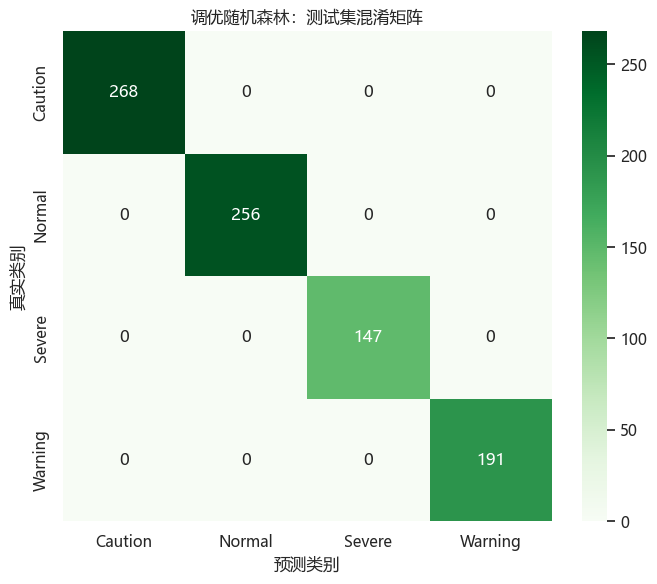

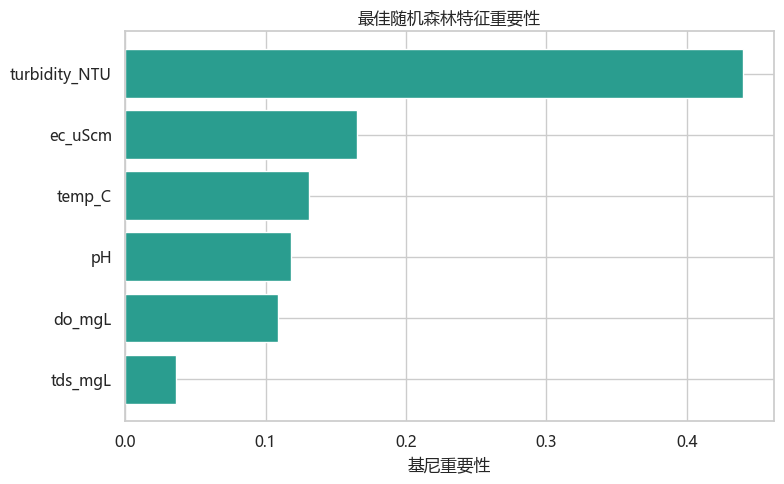

,特征,重要性
2,turbidity_NTU,0.439985
0,ec_uScm,0.165085
3,temp_C,0.131108
4,pH,0.118074
5,do_mgL,0.109212
1,tds_mgL,0.036536


In [10]:
# 最终测试集评估与特征重要性
final_pred = best_model.predict(X_test)
final_prob = best_model.predict_proba(X_test)
final_accuracy = accuracy_score(y_test, final_pred)
final_f1_weighted = f1_score(y_test, final_pred, average='weighted')
final_f1_macro = f1_score(y_test, final_pred, average='macro')

print(f'最终测试集准确率: {final_accuracy:.4f}')
print(f'最终测试集加权 F1: {final_f1_weighted:.4f}')
print(f'最终测试集宏平均 F1: {final_f1_macro:.4f}')
print('\n分类报告:')
print(classification_report(y_test, final_pred, target_names=class_names))

cm = confusion_matrix(y_test, final_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('调优随机森林：测试集混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '最佳模型混淆矩阵.png', dpi=300, bbox_inches='tight')
plt.show()

rf_model = best_model.named_steps['model']
importance_df = pd.DataFrame({'特征': feature_columns, '重要性': rf_model.feature_importances_}).sort_values('重要性', ascending=True)
plt.figure(figsize=(8, 5))
plt.barh(importance_df['特征'], importance_df['重要性'], color='#2a9d8f')
plt.title('最佳随机森林特征重要性')
plt.xlabel('基尼重要性')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '最佳模型特征重要性.png', dpi=300, bbox_inches='tight')
plt.show()
display(importance_df.sort_values('重要性', ascending=False))

In [11]:
# 9. 保存最佳模型与加载验证
model_path = BASE_DIR / 'best_random_forest_pipeline.joblib'
joblib.dump({'model': best_model, 'label_encoder': label_encoder, 'feature_columns': feature_columns}, model_path)

loaded_artifact = joblib.load(model_path)
loaded_pred = loaded_artifact['model'].predict(X_test)
assert np.array_equal(final_pred, loaded_pred), '重新加载后的预测与保存前不一致。'

prediction_export = X_test.copy()
prediction_export.insert(0, id_column, df_clean.loc[X_test.index, id_column].to_numpy())
prediction_export['真实标签'] = label_encoder.inverse_transform(y_test)
prediction_export['预测标签'] = label_encoder.inverse_transform(final_pred)
for class_index, class_name in enumerate(class_names):
    prediction_export[f'概率_{class_name}'] = final_prob[:, class_index]
prediction_export.to_csv(BASE_DIR / '最优模型测试集结果.csv', index=False, encoding='utf-8-sig')

print(f'最佳模型已保存: {model_path.name}')
print('已验证：重新加载模型的测试集预测与保存前完全一致。')

最佳模型已保存: best_random_forest_pipeline.joblib
已验证：重新加载模型的测试集预测与保存前完全一致。


In [12]:
# 10. 对新样本进行水质等级预测
# 修改下方六项指标即可进行实际预测；数值单位需与训练数据保持一致。
new_samples = pd.DataFrame([
    {'ec_uScm': 350.0, 'tds_mgL': 180.0, 'turbidity_NTU': 12.0, 'temp_C': 27.0, 'pH': 7.4, 'do_mgL': 7.0},
    {'ec_uScm': 1800.0, 'tds_mgL': 900.0, 'turbidity_NTU': 110.0, 'temp_C': 33.0, 'pH': 9.2, 'do_mgL': 3.0}
])

saved_model = loaded_artifact['model']
saved_encoder = loaded_artifact['label_encoder']
predicted_codes = saved_model.predict(new_samples[feature_columns])
predicted_probabilities = saved_model.predict_proba(new_samples[feature_columns])

new_sample_results = new_samples.copy()
new_sample_results['预测类别'] = saved_encoder.inverse_transform(predicted_codes)
for class_index, class_name in enumerate(saved_encoder.classes_):
    new_sample_results[f'概率_{class_name}'] = predicted_probabilities[:, class_index]
display(new_sample_results)

,ec_uScm,tds_mgL,turbidity_NTU,temp_C,pH,do_mgL,预测类别,概率_Caution,概率_Normal,概率_Severe,概率_Warning
0,350.0,180.0,12.0,27.0,7.4,7.0,Normal,0.0,1.0,0.0,0.0
1,1800.0,900.0,110.0,33.0,9.2,3.0,Warning,0.0,0.0,0.0,1.0
